In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import make_classification

In [2]:
X,y=make_classification(n_samples=1000, n_classes=2, random_state=7)
print(X[:10])
print(y[:10])

[[ 0.32410287 -0.32427092  0.2170448   1.48360801  0.91909763 -0.25537692
  -0.24278869  1.68001395 -0.68921753  1.82403622 -0.96307481 -1.31597009
   0.37298828 -1.11520015  1.08256169 -1.12463255  1.77782576  0.57091151
   2.2707593   1.03393349]
 [-0.22234964 -0.25180603 -0.80319531  0.4270064  -0.43205335  0.17643606
  -0.03972531  0.00409453 -0.1275947  -0.03937826  0.85881466 -1.11722625
   0.27446425  0.09608768  0.01491098 -1.26008788  2.24635167  1.54305705
  -0.85458133 -0.85913224]
 [ 0.61331335 -0.3269236  -0.00924015 -0.05434936  1.7693359   0.31246946
  -2.20630932 -0.18439188 -0.62271371 -1.14731074  0.38821749 -0.77826004
  -0.26484762 -0.93371123 -0.49190686  0.20827393  1.2784197   0.79346627
   1.77066258 -1.59873692]
 [-0.70588427  0.16078903  1.42689609  0.95564202 -0.39101612  0.36719657
   1.05808099  0.59340644  1.30555046 -0.17306602  0.3784533  -1.87472476
   0.44978598 -0.00791985 -0.82002589  0.11320309  0.04831244 -0.92422664
   0.40028193  1.917115  ]
 [-0

In [3]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=7)

## Create a Dummy probability thet gives always results as Zero(0)

In [4]:
dummy_proba= [0 for i in range(len(y_test))]


In [7]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)



LogisticRegression()

In [8]:
y_pred=model.predict(X_test)

In [14]:
model_proba=model.predict_proba(X_test)
model_proba[:10]

array([[9.43766328e-04, 9.99056234e-01],
       [2.97729259e-04, 9.99702271e-01],
       [1.47993427e-03, 9.98520066e-01],
       [9.18645191e-01, 8.13548088e-02],
       [2.99219397e-03, 9.97007806e-01],
       [2.27678831e-03, 9.97723212e-01],
       [1.54667524e-05, 9.99984533e-01],
       [2.01304769e-03, 9.97986952e-01],
       [4.33710012e-02, 9.56628999e-01],
       [9.96601105e-01, 3.39889455e-03]])

In [15]:
model_proba[:,1][:10]

array([0.99905623, 0.99970227, 0.99852007, 0.08135481, 0.99700781,
       0.99772321, 0.99998453, 0.99798695, 0.956629  , 0.00339889])

In [16]:
from sklearn.metrics import roc_auc_score, roc_curve
dummy_roc_auc= roc_auc_score(y_test,dummy_proba)
dummy_roc_auc

0.5

In [20]:
model_roc_auc= roc_auc_score(y_test,model_proba[:,1])
model_roc_auc

0.9743952650540401

In [24]:
dummy_roc_fpr,dumm_roc_tpr,_= roc_curve(y_test,dummy_proba)
dummy_roc_fpr,dumm_roc_tpr,_

(array([0., 1.]), array([0., 1.]), array([inf,  0.]))

In [34]:
model_roc_fpr,model_roc_tpr,thresholds= roc_curve(y_test,model_proba[:,1])
model_roc_fpr

array([0.        , 0.        , 0.        , 0.00746269, 0.00746269,
       0.01492537, 0.01492537, 0.02238806, 0.02238806, 0.03731343,
       0.03731343, 0.05223881, 0.05223881, 0.08955224, 0.08955224,
       0.10447761, 0.10447761, 0.12686567, 0.12686567, 0.23880597,
       0.23880597, 0.52238806, 0.52238806, 0.70895522, 0.70895522,
       0.91791045, 0.91791045, 1.        ])

In [35]:
model_roc_tpr

array([0.        , 0.00862069, 0.82758621, 0.82758621, 0.87931034,
       0.87931034, 0.89655172, 0.89655172, 0.9137931 , 0.9137931 ,
       0.92241379, 0.92241379, 0.93965517, 0.93965517, 0.94827586,
       0.94827586, 0.95689655, 0.95689655, 0.96551724, 0.96551724,
       0.97413793, 0.97413793, 0.98275862, 0.98275862, 0.99137931,
       0.99137931, 1.        , 1.        ])

In [36]:
thresholds

array([           inf, 9.99984533e-01, 8.73254303e-01, 8.60859155e-01,
       7.92832840e-01, 7.89841294e-01, 6.99038060e-01, 6.72151225e-01,
       5.31199689e-01, 4.88582699e-01, 4.88056300e-01, 4.66701219e-01,
       4.44821200e-01, 3.67470925e-01, 3.60180240e-01, 3.07840266e-01,
       3.02236716e-01, 2.81030429e-01, 2.79545180e-01, 1.74709485e-01,
       1.69892300e-01, 6.54915849e-02, 6.45362250e-02, 3.12886061e-02,
       3.01909041e-02, 6.61504799e-03, 6.53312634e-03, 1.23515747e-04])

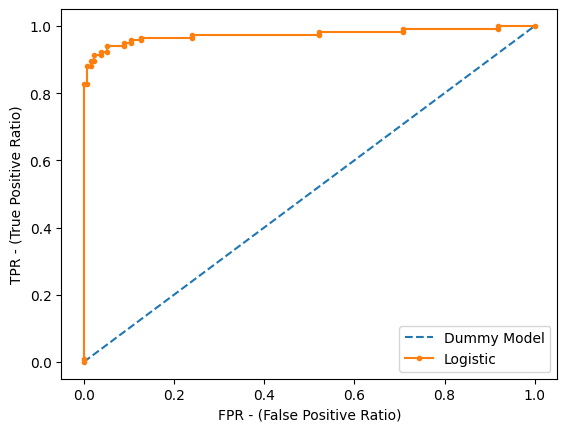

In [33]:
plt.plot(dummy_roc_fpr,dumm_roc_tpr, linestyle="--", label="Dummy Model")
plt.plot(model_roc_fpr,model_roc_tpr, marker=".", label="Logistic")
plt.xlabel("FPR - (False Positive Ratio)")
plt.ylabel("TPR - (True Positive Ratio)")
plt.legend()
plt.show()

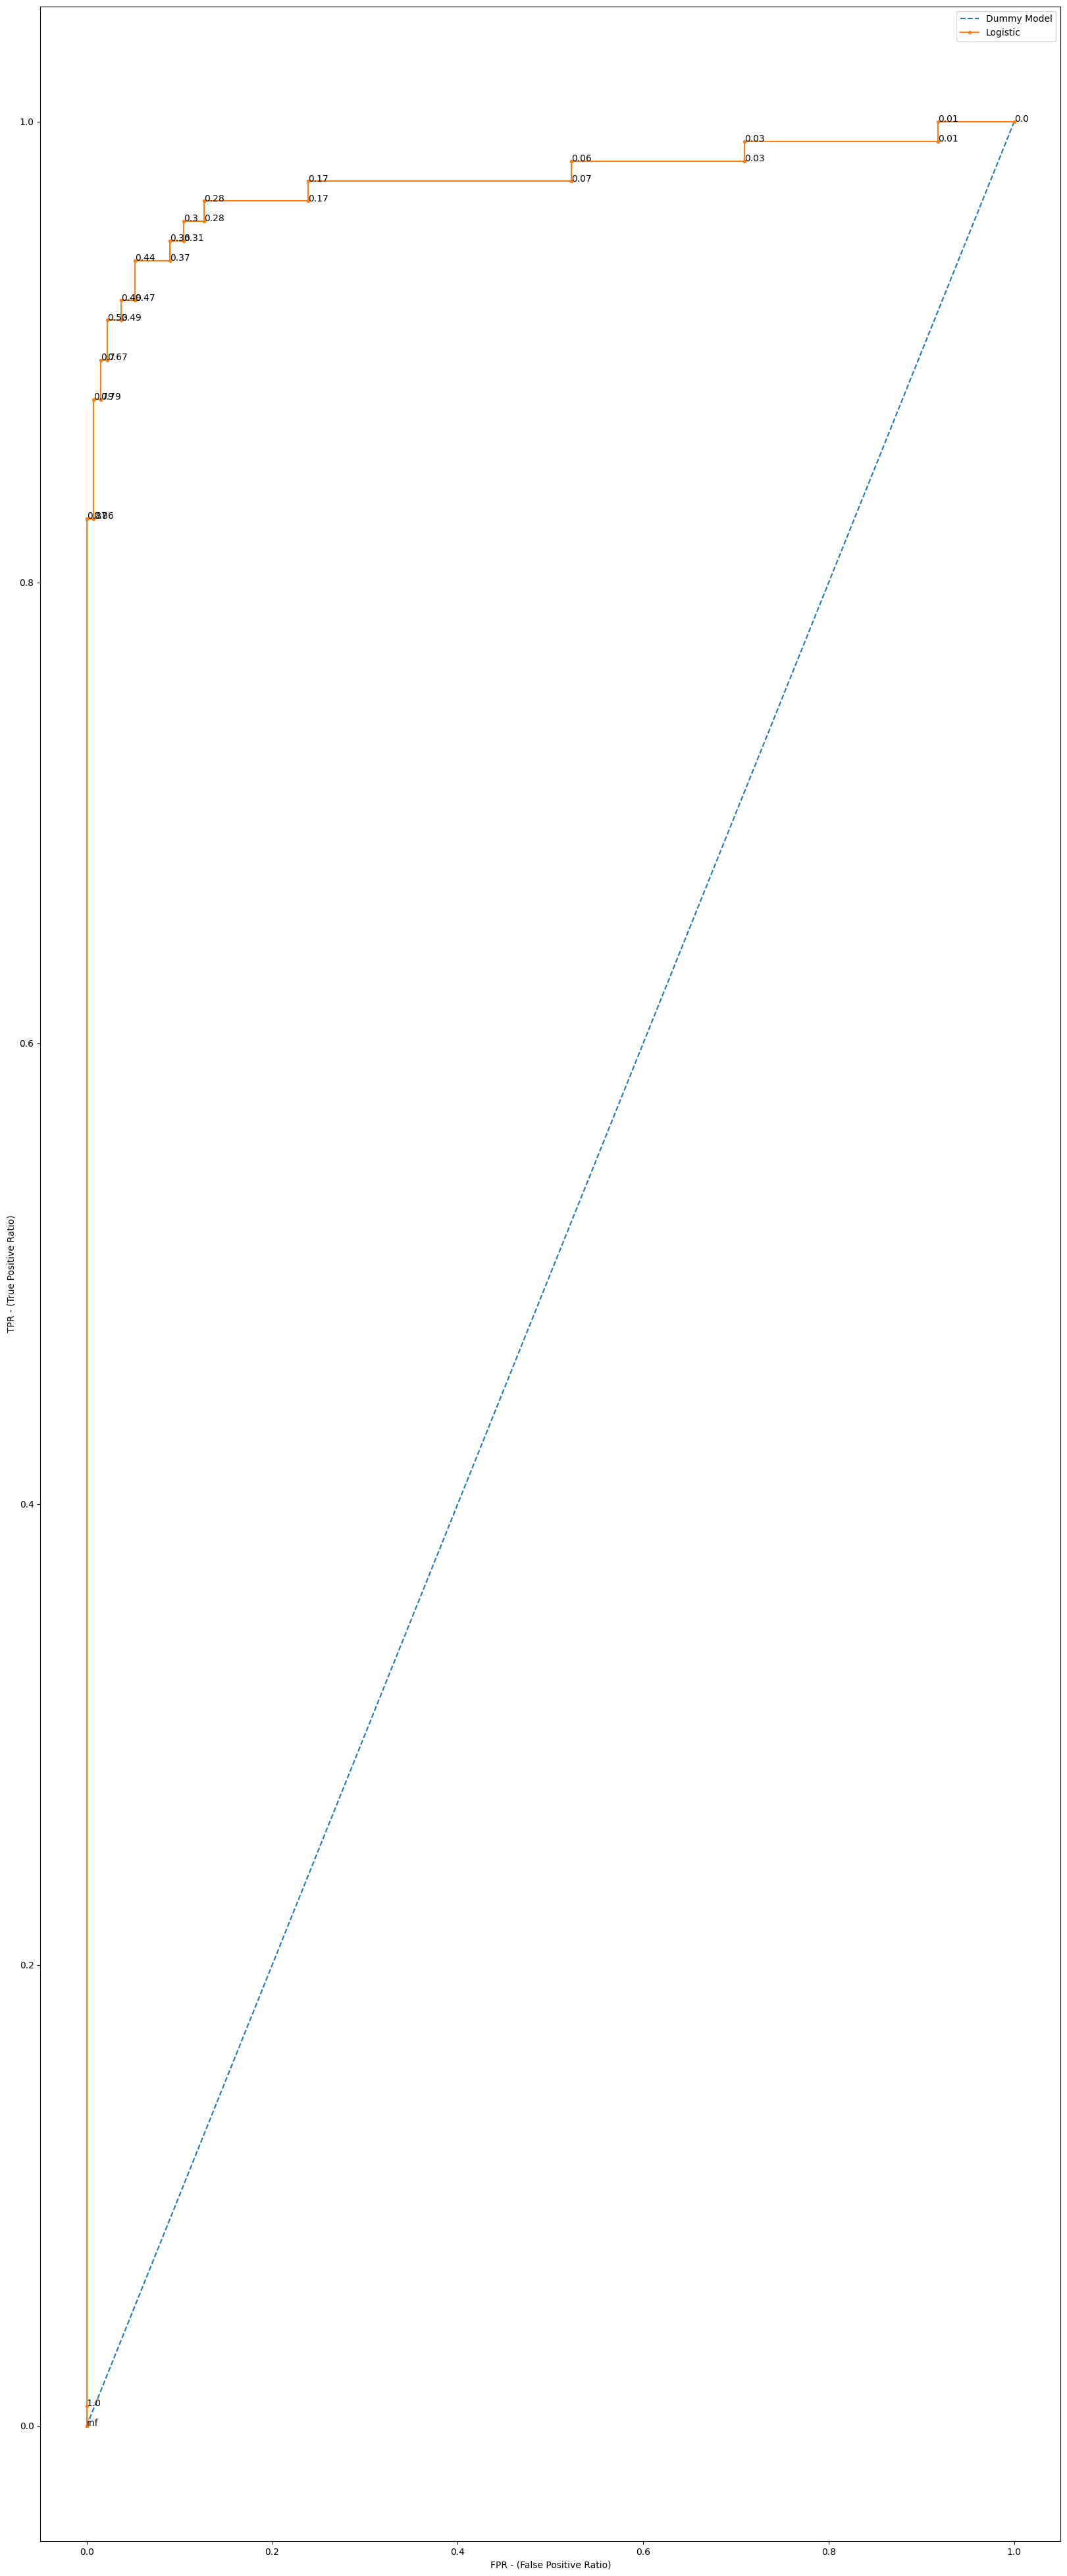

In [61]:
import numpy as np
fig=plt.figure(figsize=(20,50))
plt.plot(dummy_roc_fpr,dumm_roc_tpr, linestyle="--", label="Dummy Model")
plt.plot(model_roc_fpr,model_roc_tpr,marker=".",label="Logistic")
# ax=fig.add_subplot(111)
for xyz in zip(model_roc_fpr,model_roc_tpr, thresholds):
  plt.annotate('%s' % np.round(xyz[2],2),xy=(xyz[0],xyz[1]))
plt.xlabel("FPR - (False Positive Ratio)")
plt.ylabel("TPR - (True Positive Ratio)")
plt.legend()
plt.show()